Part (a): Ground state for V0 = 1
Ground state energy: E₀ = -0.308126
Expected bound state condition: E₀ should be < 0 for bound state
V0 = 1.0, so bound state energy should be between -V0 and 0
✓ Ground state is bound (E₀ = -0.3081 < 0)


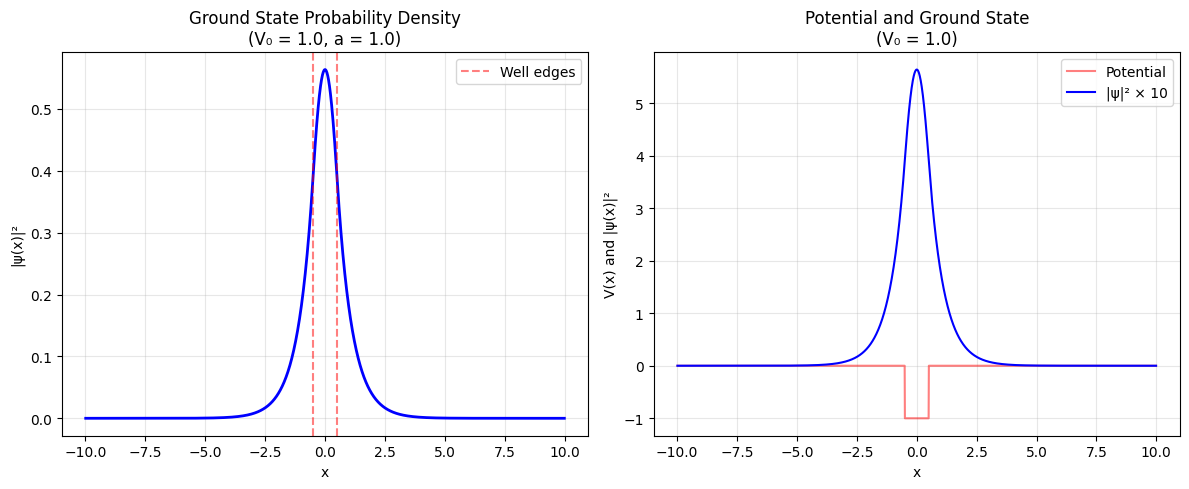


Part (b): Sudden change to V0 = 25


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


Initial ground state normalization: 1.000000 (should be ~1)

Sum of |c_n|²: 1.000000 (should be 1)


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling 

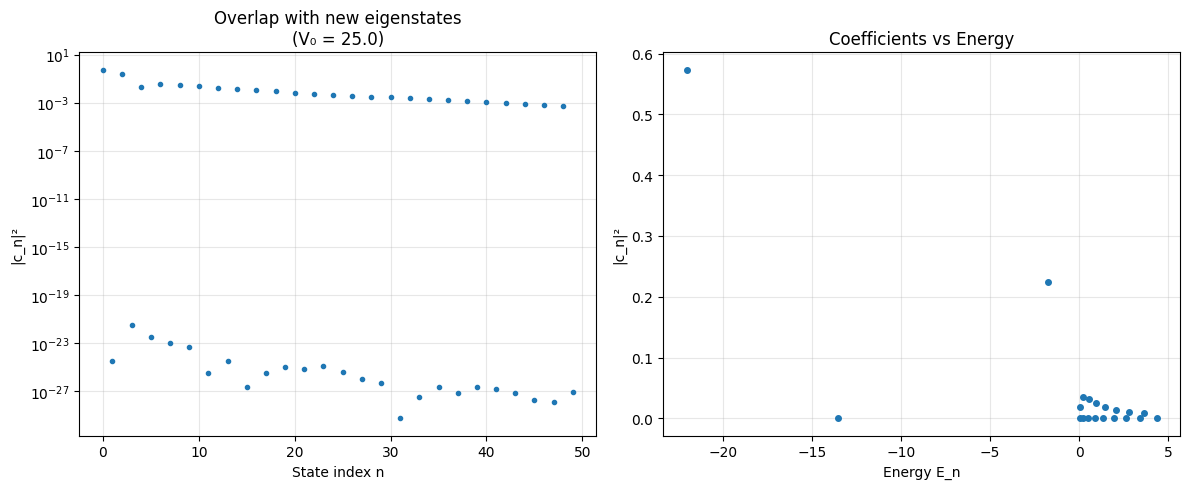


First 10 coefficients:
n	E_n		|c_n|²
----------------------------------------
0	-22.0320	0.573879
1	-13.5237	0.000000
2	-1.7679	0.224005
3	0.0540	0.000000
4	0.0587	0.019353
5	0.2159	0.000000
6	0.2340	0.034364
7	0.4855	0.000000
8	0.5240	0.031530
9	0.8625	0.000000

Time-dependent wavefunction


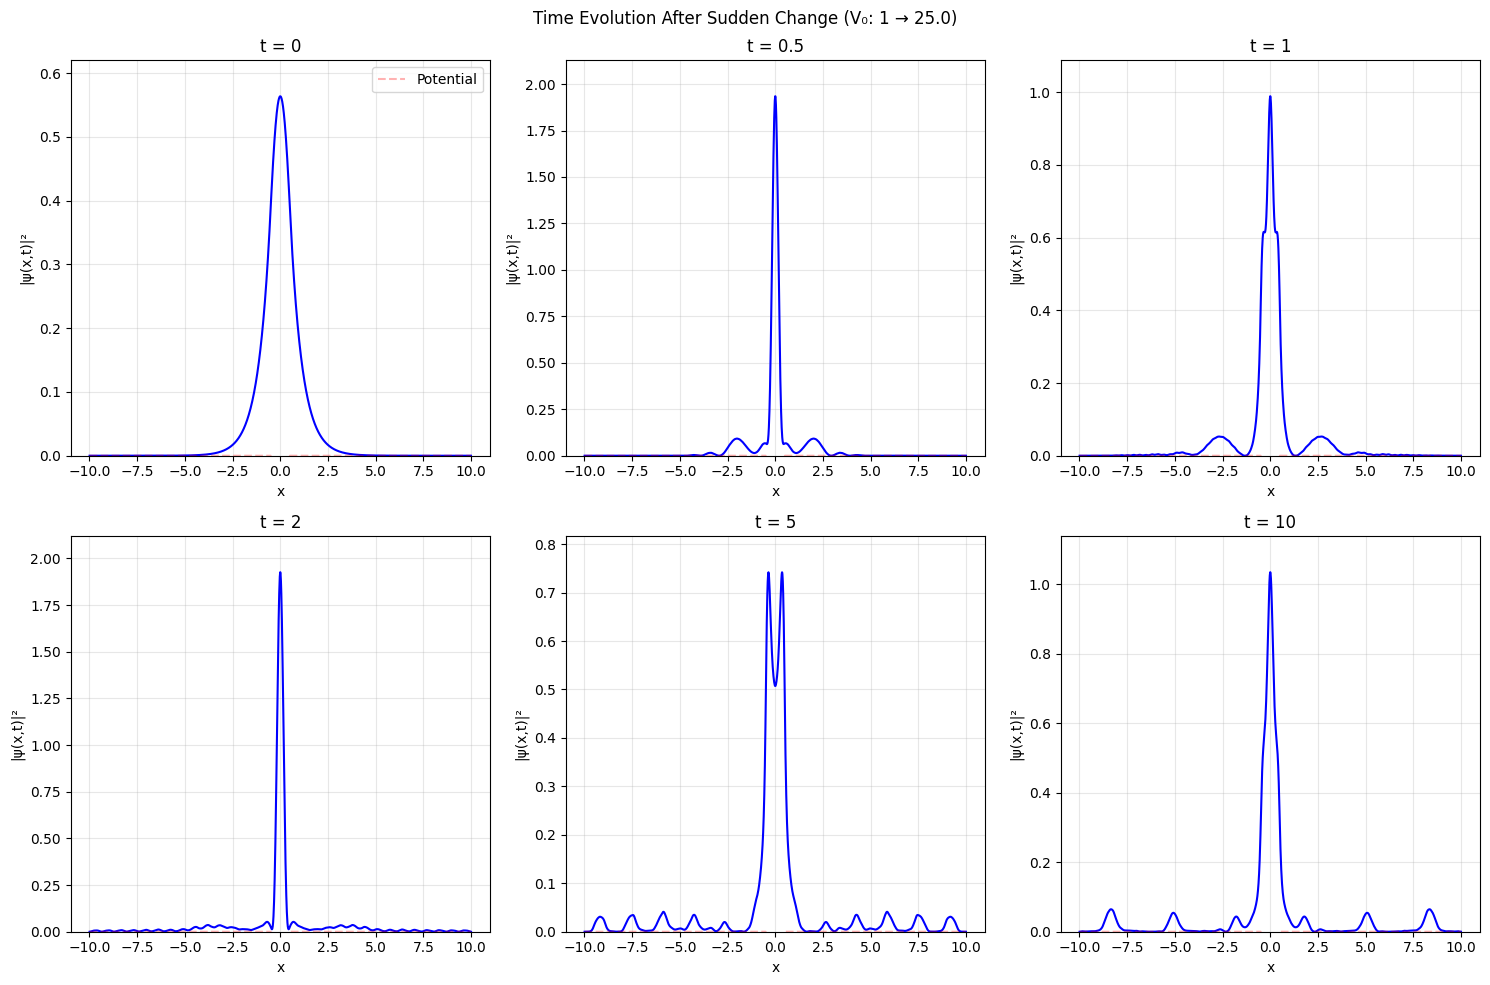


Part (c): Qualitative explanation

For a slow (adiabatic) change of the potential from V₀ = 1 to V₀ = 25:

1. The system remains in the instantaneous ground state of the changing Hamiltonian.
2. The wavefunction evolves continuously, always adapting to the current potential shape.
3. Unlike the sudden change (which projects onto many eigenstates), a slow change 
   results in negligible transitions to excited states.
4. The probability density will gradually:
   - Become more localized inside the deeper well
   - Develop faster oscillations (since the ground state energy decreases)
   - Maintain its shape as the ground state of the instantaneous potential

5. The adiabatic theorem guarantees that if the change is infinitely slow, 
   the system stays in the instantaneous eigenstate with no transitions to 
   other states.


Number of states with |c_n|² > 0.01: 9
Largest coefficient: |c_0|² = 0.573879


In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Constants
hbar = 1.0
m = 1.0
a = 1.0  # Full width of the well (from -a/2 to a/2)
half_width = a / 2

# Grid parameters
x_min = -10  # Large enough to contain bound states
x_max = 10
N = 2000  # Increased for better accuracy

dx = (x_max - x_min) / (N - 1)
N_int = N - 2  # Interior points (excluding boundaries where ψ=0)
x_int = np.linspace(x_min + dx, x_max - dx, N_int)

def build_hamiltonian(V0, x_int, half_width, dx):
    """
    Build the Hamiltonian matrix for a finite square well
    V(x) = -V0 for |x| < half_width, 0 elsewhere
    """
    # Potential: -V0 inside the well, 0 outside
    V_j = np.where(np.abs(x_int) < half_width, -V0, 0.0)
    
    # Kinetic energy coefficient
    t = -(hbar**2) / (2.0 * m * dx**2)
    
    # Diagonal elements
    d_j = (hbar**2) / (m * dx**2) + V_j
    
    # Build tridiagonal Hamiltonian matrix
    H = np.diag(d_j) + np.diag(t * np.ones(N_int - 1), 1) + np.diag(t * np.ones(N_int - 1), -1)
    
    return H, V_j

# Part (a): Initial state with V0 = 1
print("=" * 50)
print("Part (a): Ground state for V0 = 1")
print("=" * 50)

V0_initial = 1.0
H_initial, V_initial = build_hamiltonian(V0_initial, x_int, half_width, dx)
energies_initial, evecs_initial = la.eigh(H_initial)

# Normalize wavefunctions (evecs are already orthonormal with dx weighting)
# Actually, evecs are normalized such that evecs^T @ evecs = I
# But our wavefunctions on the grid are ψ(x_i) = evecs[i] / sqrt(dx)
wavefunctions_initial = evecs_initial / np.sqrt(dx)

# Ground state (index 0)
psi_ground = wavefunctions_initial[:, 0]
E_ground = energies_initial[0]

print(f"Ground state energy: E₀ = {E_ground:.6f}")
print(f"Expected bound state condition: E₀ should be < 0 for bound state")
print(f"V0 = {V0_initial}, so bound state energy should be between -V0 and 0")

# Check if ground state is bound
if E_ground < 0:
    print(f"✓ Ground state is bound (E₀ = {E_ground:.4f} < 0)")
else:
    print(f"✗ Ground state is not bound (E₀ = {E_ground:.4f} > 0)")

# Plot probability density for ground state
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_int, np.abs(psi_ground)**2, 'b-', linewidth=2)
plt.xlabel('x')
plt.ylabel('|ψ(x)|²')
plt.title(f'Ground State Probability Density\n(V₀ = {V0_initial}, a = {a})')
plt.grid(True, alpha=0.3)
plt.axvline(-half_width, color='r', linestyle='--', alpha=0.5, label='Well edges')
plt.axvline(half_width, color='r', linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_int, V_initial, 'r-', alpha=0.5, label='Potential')
plt.plot(x_int, np.abs(psi_ground)**2 * 10, 'b-', label='|ψ|² × 10')
plt.xlabel('x')
plt.ylabel('V(x) and |ψ(x)|²')
plt.title(f'Potential and Ground State\n(V₀ = {V0_initial})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Part (b): Sudden change to V0 = 25
print("\n" + "=" * 50)
print("Part (b): Sudden change to V0 = 25")
print("=" * 50)

V0_new = 25.0
H_new, V_new = build_hamiltonian(V0_new, x_int, half_width, dx)
energies_new, evecs_new = la.eigh(H_new)
wavefunctions_new = evecs_new / np.sqrt(dx)

# Compute overlap coefficients c_n = <φ_n_new|ψ_initial>
# Need to be careful: wavefunctions are on grid, so integral is sum(ψ₁* ψ₂) * dx
# Since wavefunctions_new and psi_ground are on same grid, and we've normalized properly:
# ∫ ψ₁* ψ₂ dx ≈ Σ ψ₁*(x_i) ψ₂(x_i) dx
# Our wavefunctions are stored as ψ(x_i), so we need to multiply by dx

# First, check normalization
norm_psi_ground = np.sum(np.abs(psi_ground)**2) * dx
print(f"Initial ground state normalization: {norm_psi_ground:.6f} (should be ~1)")

# Compute overlaps
c_n = np.zeros(len(energies_new))
for n in range(len(energies_new)):
    # c_n = ∫ φ_n_new*(x) ψ_initial(x) dx
    c_n[n] = np.sum(np.conj(wavefunctions_new[:, n]) * psi_ground) * dx

# Check completeness (sum |c_n|² should be ~1)
sum_c2 = np.sum(np.abs(c_n)**2)
print(f"\nSum of |c_n|²: {sum_c2:.6f} (should be 1)")

# Plot coefficients
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.semilogy(np.abs(c_n[:50])**2, 'o', markersize=3)
plt.xlabel('State index n')
plt.ylabel('|c_n|²')
plt.title(f'Overlap with new eigenstates\n(V₀ = {V0_new})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(energies_new[:20], np.abs(c_n[:20])**2, 'o', markersize=4)
plt.xlabel('Energy E_n')
plt.ylabel('|c_n|²')
plt.title('Coefficients vs Energy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print first few coefficients
print("\nFirst 10 coefficients:")
print("n\tE_n\t\t|c_n|²")
print("-" * 40)
for n in range(min(10, len(energies_new))):
    print(f"{n}\t{energies_new[n]:.4f}\t{np.abs(c_n[n])**2:.6f}")

# Part (b) continued: Time evolution
print("\n" + "=" * 50)
print("Time-dependent wavefunction")
print("=" * 50)

# Define time evolution function
def time_evolution(t, x_int, c_n, energies_new, wavefunctions_new):
    """Compute ψ(x,t) = Σ c_n φ_n(x) e^{-iE_n t}"""
    psi_t = np.zeros(len(x_int), dtype=complex)
    for n in range(len(c_n)):
        if np.abs(c_n[n]) > 1e-10:  # Only include significant contributions
            psi_t += c_n[n] * wavefunctions_new[:, n] * np.exp(-1j * energies_new[n] * t)
    return psi_t

# Plot probability density at different times
times = [0, 0.5, 1, 2, 5, 10]
plt.figure(figsize=(15, 10))

for idx, t in enumerate(times):
    psi_t = time_evolution(t, x_int, c_n, energies_new, wavefunctions_new)
    prob_density = np.abs(psi_t)**2
    
    plt.subplot(2, 3, idx + 1)
    plt.plot(x_int, prob_density, 'b-', linewidth=1.5)
    plt.plot(x_int, V_new, 'r--', alpha=0.3, label='Potential' if idx == 0 else "")
    plt.xlabel('x')
    plt.ylabel('|ψ(x,t)|²')
    plt.title(f't = {t}')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, max(prob_density) * 1.1)
    if idx == 0:
        plt.legend()

plt.suptitle(f'Time Evolution After Sudden Change (V₀: 1 → {V0_new})')
plt.tight_layout()
plt.show()

# Part (c): Qualitative explanation
print("\n" + "=" * 50)
print("Part (c): Qualitative explanation")
print("=" * 50)
print("""
For a slow (adiabatic) change of the potential from V₀ = 1 to V₀ = 25:

1. The system remains in the instantaneous ground state of the changing Hamiltonian.
2. The wavefunction evolves continuously, always adapting to the current potential shape.
3. Unlike the sudden change (which projects onto many eigenstates), a slow change 
   results in negligible transitions to excited states.
4. The probability density will gradually:
   - Become more localized inside the deeper well
   - Develop faster oscillations (since the ground state energy decreases)
   - Maintain its shape as the ground state of the instantaneous potential

5. The adiabatic theorem guarantees that if the change is infinitely slow, 
   the system stays in the instantaneous eigenstate with no transitions to 
   other states.
""")

# Optional: Show how many states contribute significantly
significant_states = np.sum(np.abs(c_n)**2 > 0.01)
print(f"\nNumber of states with |c_n|² > 0.01: {significant_states}")
print(f"Largest coefficient: |c_{np.argmax(np.abs(c_n)**2)}|² = {np.max(np.abs(c_n)**2):.6f}")